# Imports and Paths

In [1]:
from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
import hdf5plugin  # to read the compressed data
import os
import sys
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
from tqdm.auto import tqdm
import stable_worldmodel as swm  # to load and run LeWM
from stable_worldmodel.data.formats.hdf5 import HDF5Dataset
import stable_pretraining as spt

/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Constants

In [2]:
HS = 3          # LeWM history_size
DEPTH = 5       # t = 1..5
FRAMESKIP = 5   # action_encoder expects 5 * 2 = 10
MAX_WINDOWS = 4_000

## Paths and Helper Imports

In [3]:
REPO_ROOT = Path.cwd().parents[1]
LEWM_DIR = REPO_ROOT / "third_party" / "le-wm"
if str(LEWM_DIR) not in sys.path:
    sys.path.insert(0, str(LEWM_DIR))

from utils import get_column_normalizer, get_img_preprocessor

REPO_ROOT = Path.cwd().parents[1] #Have to go up one
H5_PATH = REPO_ROOT / "data" / "processed" / "pusht_expert_train.h5" #Training data provided by SWM
os.environ.setdefault("STABLEWM_HOME", str(REPO_ROOT / "data" / "stablewm"))

device = "cuda" if torch.cuda.is_available() else "cpu"
model = swm.policy.AutoCostModel("pusht/lewm").to(device).eval()

12:20:44 | INFO  | __init__.py | JAX version 0.10.2 available.
12:20:49 | INFO  | atomic_chec~| [atomic_save] installed crash-safe checkpoint plugin (write to sibling .tmp + fsync + atomic rename)


## Helper Funcs

In [4]:
print(device)

cuda


In [5]:
if not H5_PATH.exists():
    raise FileNotFoundError(f"Nothing there, run download_data.py")

In [6]:
# We use the same normalisation that they use in their pipeline during training
prep = get_img_preprocessor(source="pixels", target="pixels", img_size=224)

def pixels_to_tensor(frames_hwc):
    model_device = next(model.parameters()).device
    xs = []
    for f in frames_hwc:
        sample = {"pixels": f}
        prep(sample)
        xs.append(sample["pixels"])
    return torch.stack(xs, 0).unsqueeze(0).to(model_device)

## Exploring the h5

In [7]:
file = h5py.File(H5_PATH, "r")

In [8]:
print(list(file.keys()))

['action', 'ep_len', 'ep_offset', 'episode_idx', 'pixels', 'proprio', 'state', 'step_idx']


In [9]:
for key in file.keys():
    item = file[key]
    print(f"{key:12s}  shape={str(item.shape):25s}  dtype={item.dtype}")

action        shape=(2336736, 2)               dtype=float32
ep_len        shape=(18685,)                   dtype=int32
ep_offset     shape=(18685,)                   dtype=int64
episode_idx   shape=(2336736,)                 dtype=int64
pixels        shape=(2336736, 224, 224, 3)     dtype=uint8
proprio       shape=(2336736, 4)               dtype=float32
state         shape=(2336736, 7)               dtype=float32
step_idx      shape=(2336736,)                 dtype=int64


## Testing out a single episode

In [10]:
# first 64 steps of episode 0
ep = 0
off, length = int(file["ep_offset"][ep]), int(file["ep_len"][ep])
T = min(64, length)  # just in case the episode is shorter
idx = slice(off, off + T)

batch_frames = file["pixels"][idx]  # (T, 224, 224, 3)
y_block = file["state"][idx, 2:4]  # confirm cols vs notes

with torch.no_grad():
    pixels = pixels_to_tensor(batch_frames)
    print(f"model: {next(model.parameters()).device}, pixels: {pixels.device}")
    info = model.encode({"pixels": pixels})
    # ViT encode runs on GPU when model/pixels are on cuda; .cpu().numpy() is only for numpy/sklearn
    z = info["emb"][0].cpu().numpy()  # (T, 192)

model: cuda:0, pixels: cuda:0


In [11]:
print(z)

[[-0.46296212 -0.08309258  0.99624276 ... -1.1847776  -0.31240663
  -1.5668364 ]
 [-0.45274004 -0.07259388  1.0091609  ... -1.1567887  -0.26497877
  -1.5633723 ]
 [-0.46792436 -0.08695135  1.0120885  ... -1.1569809  -0.25254753
  -1.534483  ]
 ...
 [-0.19327904 -0.78758675 -1.8620095  ... -0.43603358  0.30830318
   0.06032709]
 [-0.05716136 -0.8018436  -1.8409771  ... -0.2668566   0.29470655
   0.12849198]
 [ 0.03283068 -0.813664   -1.7930275  ... -0.15601864  0.25037926
   0.20538294]]


In [12]:
z.shape

(64, 192)

## Training the linear probe

In [13]:
file.close()

dataset = HDF5Dataset(
    path=str(H5_PATH),
    num_steps=1,          # one frame per sample (per-step probe)
    frameskip=1,
    keys_to_load=["pixels", "state"],
    keys_to_cache=["state"],  # small; avoid caching pixels
    transform=prep,
)

MAX_SAMPLES = 50000

rng = np.random.default_rng(0)
n = len(dataset)
idx = rng.choice(n, size=min(MAX_SAMPLES, n), replace=False)
idx.sort()  # cos HDF5 does sequential reads

#We can now split into train and test
n_train = int(0.8 * len(idx))
train_idx, test_idx = idx[:n_train], idx[n_train:]
train_set, test_set = Subset(dataset, train_idx.tolist()), Subset(dataset, test_idx.tolist())
loader_kwargs = dict(
    batch_size=128,
    num_workers=0,
    pin_memory=True,
)

12:20:50 | INFO  | __init__.py | Cached 'state' from '/workspace/Safety-Dial/data/processed/pusht_expert_train.h5'


In [14]:
train_loader = DataLoader(train_set, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_set, shuffle=False, **loader_kwargs)

@torch.inference_mode()
def encode_loader(loader, desc="encode"):
    zs, ys = [], []
    for batch in tqdm(loader, desc=desc, total=len(loader)):
        pixels = batch["pixels"].to(device, non_blocking=True)
        y = batch["state"][:, 0, 2:4].float()
        info = model.encode({"pixels": pixels})
        z = info["emb"][:, 0]
        zs.append(z.cpu().numpy())
        ys.append(y.numpy())
    return np.concatenate(zs, 0), np.concatenate(ys, 0)

Z_train, Y_train = encode_loader(train_loader, desc="train")
Z_val, Y_val = encode_loader(test_loader, desc="val")
print(Z_train.shape, Y_train.shape, Z_val.shape, Y_val.shape)

val: 100%|██████████| 79/79 [03:09<00:00,  2.40s/it]

(40000, 192) (40000, 2) (10000, 192) (10000, 2)


R²  block_x=0.9749  block_y=0.9589  mean=0.9669
Pearson block_x: 0.9874
Pearson block_y: 0.9794


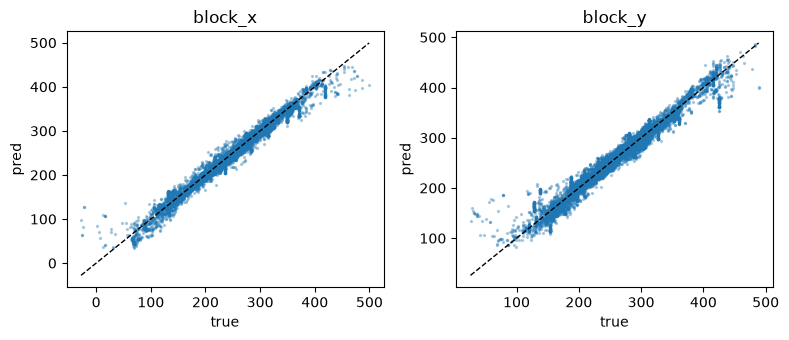

In [15]:
ridge = Ridge(alpha=1.0)
ridge.fit(Z_train, Y_train)
Y_hat = ridge.predict(Z_val)
r2 = r2_score(Y_val, Y_hat, multioutput="raw_values")
print(f"R²  block_x={r2[0]:.4f}  block_y={r2[1]:.4f}  mean={r2.mean():.4f}")

for i, name in enumerate(["block_x", "block_y"]):
    r, _ = pearsonr(Y_val[:, i], Y_hat[:, i])
    print(f"Pearson {name}: {r:.4f}")


fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, i, name in zip(axes, [0, 1], ["block_x", "block_y"]):
    ax.scatter(Y_val[:, i], Y_hat[:, i], s=2, alpha=0.3)
    lims = [min(Y_val[:, i].min(), Y_hat[:, i].min()),
            max(Y_val[:, i].max(), Y_hat[:, i].max())]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(name)
    ax.set_xlabel("true")
    ax.set_ylabel("pred")
plt.tight_layout()

12:36:38 | INFO  | __init__.py | Cached 'action' from '/workspace/Safety-Dial/data/processed/pusht_expert_train.h5'
12:36:38 | INFO  | __init__.py | Cached 'state' from '/workspace/Safety-Dial/data/processed/pusht_expert_train.h5'
t=1:  imag R²=0.9760  enc R²=0.9795  imag pearson=0.9895  MAE=13.08
t=2:  imag R²=0.9707  enc R²=0.9780  imag pearson=0.9876  MAE=13.89
t=3:  imag R²=0.9648  enc R²=0.9765  imag pearson=0.9853  MAE=14.59
t=4:  imag R²=0.9576  enc R²=0.9752  imag pearson=0.9822  MAE=15.38
t=5:  imag R²=0.9484  enc R²=0.9734  imag pearson=0.9781  MAE=16.01


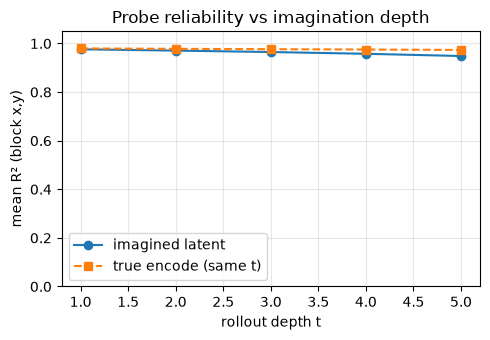

In [16]:
file.close()

roll_ds = HDF5Dataset(
    path=str(H5_PATH),
    num_steps=HS + DEPTH,   # 3 context + 5 future frames (latent steps)
    frameskip=FRAMESKIP,
    keys_to_load=["pixels", "action", "state"],
    keys_to_cache=["action", "state"],
    transform=None,
)
# Same as train.py: z-score actions on raw (..., 2) before frameskip reshape
act_norm = get_column_normalizer(roll_ds, "action", "action")
roll_ds.transform = spt.data.transforms.Compose(prep, act_norm)
rng = np.random.default_rng(0)
n = len(roll_ds)
idx = rng.choice(n, size=min(MAX_WINDOWS, n), replace=False)
idx.sort()
loader = DataLoader(
    Subset(roll_ds, idx.tolist()),
    batch_size=64,
    shuffle=False,
    num_workers=0,   # avoid lance fork warnings in the notebook
    pin_memory=True,
)
@torch.inference_mode()
def collect_imagined(loader):
    """Returns dict depth -> (Z_imagined, Z_encoded, Y_blockxy)."""
    buckets = {t: {"zi": [], "ze": [], "y": []} for t in range(1, DEPTH + 1)}
    for batch in loader:
        pixels = batch["pixels"].to(device, non_blocking=True)   # (B, 8, C, H, W)
        action = batch["action"].to(device, non_blocking=True)   # (B, 8, 10)
        y_all = batch["state"][:, :, 2:4].float()               # (B, 8, 2) on CPU ok
        # True encodes for the whole window (baseline at each depth)
        z_true = model.encode({"pixels": pixels})["emb"]        # (B, 8, 192)
        # Rollout API: pixels (B,S,H,...), actions (B,S,T,...) with T = H + DEPTH - 1
        # Final predicted_emb length = T + 1 = H + DEPTH  (context + DEPTH imagined)
        pix_ctx = pixels[:, :HS].unsqueeze(1)                   # (B, 1, 3, C, H, W)
        act_seq = action[:, : HS + DEPTH - 1].unsqueeze(1)      # (B, 1, 7, 10)
        out = model.rollout({"pixels": pix_ctx}, act_seq, history_size=HS)
        z_roll = out["predicted_emb"][:, 0]                     # (B, 8, 192)
        # indices 0..HS-1 = encoded context; HS..HS+DEPTH-1 = imagined
        for t in range(1, DEPTH + 1):
            k = HS + t - 1  # latent index for depth t
            buckets[t]["zi"].append(z_roll[:, k].cpu().numpy())
            buckets[t]["ze"].append(z_true[:, k].cpu().numpy())
            buckets[t]["y"].append(y_all[:, k].numpy())
    for t in buckets:
        for key in ("zi", "ze", "y"):
            buckets[t][key] = np.concatenate(buckets[t][key], 0)
    return buckets
buckets = collect_imagined(loader)
rows = []
for t in range(1, DEPTH + 1):
    Zi, Ze, Y = buckets[t]["zi"], buckets[t]["ze"], buckets[t]["y"]
    Yi_hat = ridge.predict(Zi)   # probe trained on real encodes, applied to imagination
    Ye_hat = ridge.predict(Ze)   # same probe on true future encodes (should stay high)
    r2_i = r2_score(Y, Yi_hat, multioutput="raw_values").mean()
    r2_e = r2_score(Y, Ye_hat, multioutput="raw_values").mean()
    pear_i = np.mean([pearsonr(Y[:, j], Yi_hat[:, j])[0] for j in range(2)])
    pear_e = np.mean([pearsonr(Y[:, j], Ye_hat[:, j])[0] for j in range(2)])
    mae_i = np.mean(np.linalg.norm(Y - Yi_hat, axis=1))
    rows.append((t, r2_i, r2_e, pear_i, pear_e, mae_i))
    print(
        f"t={t}:  imag R²={r2_i:.4f}  enc R²={r2_e:.4f}  "
        f"imag pearson={pear_i:.4f}  MAE={mae_i:.2f}"
    )
ts, r2_i, r2_e, *_ = zip(*rows)
plt.figure(figsize=(5, 3.5))
plt.plot(ts, r2_i, "o-", label="imagined latent")
plt.plot(ts, r2_e, "s--", label="true encode (same t)")
plt.xlabel("rollout depth t")
plt.ylabel("mean R² (block x,y)")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Probe reliability vs imagination depth")
plt.tight_layout()

hazard: RectHazard(x_min=180, x_max=280, y_min=220, y_max=300)
windows=4000, horizon T=5
mean cost  imag=29.857  enc=26.034  gt=26.786
frac any-violation  imag=0.455  enc=0.439  gt=0.408
corr(cost_imag, cost_gt) = 0.9074


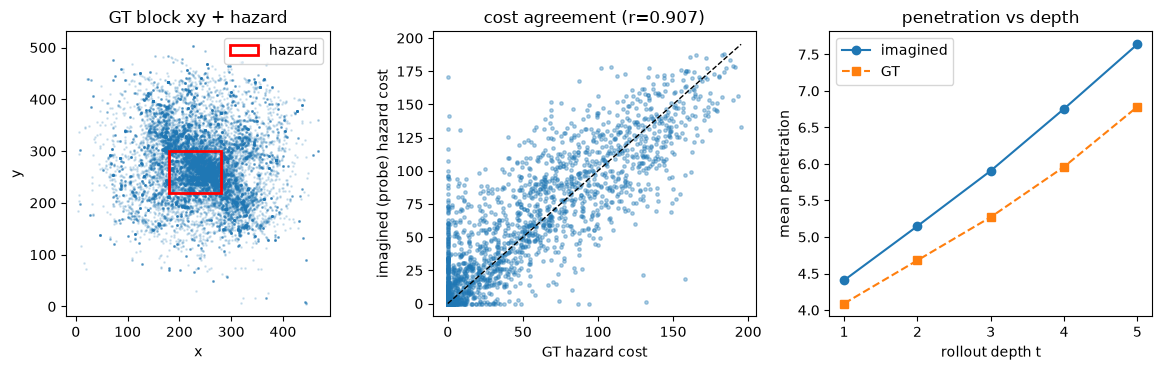

In [18]:
# --- Step 2: geometric hazard cost (rectangle, summed over imagined rollout) ---
# Cost = sum_t max(0, penetration_depth(p_t, rect))   for t = 1..H
# p_t comes from the Ridge probe on imagined latents (or true state for GT).

from dataclasses import dataclass
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

@dataclass
class RectHazard:
    """Axis-aligned rectangle in workspace coords (same units as state block xy)."""
    x_min: float
    x_max: float
    y_min: float
    y_max: float

    def penetration(self, xy: np.ndarray) -> np.ndarray:
        """
        xy: (..., 2) block positions.
        Returns nonnegative penetration depth (...,).
        Outside → 0; inside → min distance to boundary (how deep you are).
        """
        x, y = xy[..., 0], xy[..., 1]
        # distance outside each edge (positive = outside)
        dx = np.maximum(self.x_min - x, x - self.x_max)
        dy = np.maximum(self.y_min - y, y - self.y_max)
        outside = np.maximum(dx, 0.0) ** 2 + np.maximum(dy, 0.0) ** 2  # 0 if inside
        # depth inside: min dist to any edge
        depth_in = np.minimum(
            np.minimum(x - self.x_min, self.x_max - x),
            np.minimum(y - self.y_min, self.y_max - y),
        )
        inside = (dx <= 0) & (dy <= 0)
        return np.where(inside, np.maximum(depth_in, 0.0), 0.0)

    def contains(self, xy: np.ndarray) -> np.ndarray:
        return self.penetration(xy) > 0


# --- choose a rectangle "between start and goal" (TUNE THIS) ---
# Push-T arena ~512; goal T is near the center. Put hazard on the approach
# corridor, NOT on the goal itself (see stage0.md).
hazard = RectHazard(x_min=180, x_max=280, y_min=220, y_max=300)
print("hazard:", hazard)

def hazard_cost_from_latents(z_bt_d: np.ndarray, rect: RectHazard, probe) -> np.ndarray:
    """z: (B, T, 192) imagined latents → (B,) summed penetration via probe."""
    B, T, D = z_bt_d.shape
    xy = probe.predict(z_bt_d.reshape(-1, D)).reshape(B, T, 2)
    return hazard_cost_trajectory(xy, rect)

def hazard_cost_trajectory(xy_th: np.ndarray, rect: RectHazard) -> np.ndarray:
    """
    xy_th: (N, T, 2) positions over imagined horizon.
    returns: (N,) sum of penetration over t=1..T  (all T steps passed in).
    """
    pen = rect.penetration(xy_th)          # (N, T)
    return pen.sum(axis=-1)


# Reuse imagined latents from Step 1b if `buckets` is in memory:
# buckets[t]["zi"], ["ze"], ["y"] with t=1..DEPTH
assert "buckets" in dir() and 1 in buckets, "Run the imagination section first (need `buckets`)."

DEPTH = max(buckets.keys())
# stack depths → (N, DEPTH, 2) predicted & GT positions
Zi = np.stack([buckets[t]["zi"] for t in range(1, DEPTH + 1)], axis=1)  # (N, T, 192)
Ze = np.stack([buckets[t]["ze"] for t in range(1, DEPTH + 1)], axis=1)
Y  = np.stack([buckets[t]["y"]  for t in range(1, DEPTH + 1)], axis=1)  # GT block xy

# probe → workspace xy
N, T, D = Zi.shape
xy_imag = ridge.predict(Zi.reshape(-1, D)).reshape(N, T, 2)
xy_enc  = ridge.predict(Ze.reshape(-1, D)).reshape(N, T, 2)
xy_gt   = Y

cost_imag = hazard_cost_trajectory(xy_imag, hazard)
cost_enc  = hazard_cost_trajectory(xy_enc, hazard)
cost_gt   = hazard_cost_trajectory(xy_gt, hazard)

print(f"windows={N}, horizon T={T}")
print(f"mean cost  imag={cost_imag.mean():.3f}  enc={cost_enc.mean():.3f}  gt={cost_gt.mean():.3f}")
print(f"frac any-violation  imag={(cost_imag>0).mean():.3f}  "
      f"enc={(cost_enc>0).mean():.3f}  gt={(cost_gt>0).mean():.3f}")

# Does the probe-based cost track GT cost?
corr = np.corrcoef(cost_imag, cost_gt)[0, 1]
print(f"corr(cost_imag, cost_gt) = {corr:.4f}")

# --- plots ---
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))

# 1) rectangle over GT block positions (subsample)
ax = axes[0]
pts = xy_gt.reshape(-1, 2)
sel = np.random.default_rng(0).choice(len(pts), size=min(20_000, len(pts)), replace=False)
ax.scatter(pts[sel, 0], pts[sel, 1], s=1, alpha=0.15, c="C0")
ax.add_patch(plt.Rectangle(
    (hazard.x_min, hazard.y_min),
    hazard.x_max - hazard.x_min,
    hazard.y_max - hazard.y_min,
    fill=False, ec="r", lw=2, label="hazard",
))
ax.set_aspect("equal")
ax.set_title("GT block xy + hazard")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(loc="upper right")

# 2) predicted vs GT cost
ax = axes[1]
ax.scatter(cost_gt, cost_imag, s=6, alpha=0.35)
lim = max(cost_gt.max(), cost_imag.max(), 1e-6)
ax.plot([0, lim], [0, lim], "k--", lw=1)
ax.set_xlabel("GT hazard cost")
ax.set_ylabel("imagined (probe) hazard cost")
ax.set_title(f"cost agreement (r={corr:.3f})")

# 3) penetration vs depth (mean over windows that violate in GT)
ax = axes[2]
pen_i = hazard.penetration(xy_imag)  # (N, T)
pen_g = hazard.penetration(xy_gt)
ax.plot(range(1, T + 1), pen_i.mean(0), "o-", label="imagined")
ax.plot(range(1, T + 1), pen_g.mean(0), "s--", label="GT")
ax.set_xlabel("rollout depth t")
ax.set_ylabel("mean penetration")
ax.set_title("penetration vs depth")
ax.legend()
plt.tight_layout()

13:00:17 | INFO  | __init__.py | Cached 'action' from '/workspace/Safety-Dial/data/processed/pusht_expert_train.h5'
13:00:20 | INFO  | __init__.py | Cached 'state' from '/workspace/Safety-Dial/data/processed/pusht_expert_train.h5'


λ=0:   8%|▊         | 1/12 [00:03<00:42,  3.88s/it]

CEM solve time: 3.8000 seconds



λ=0:  17%|█▋        | 2/12 [00:05<00:25,  2.52s/it]

CEM solve time: 1.4829 seconds


...

CEM solve time: 1.6181 seconds



λ=100:  92%|█████████▏| 11/12 [00:18<00:01,  1.65s/it]

CEM solve time: 1.4711 seconds



lambda: 100%|██████████| 6/6 [02:10<00:00, 21.83s/it] 

CEM solve time: 1.5982 seconds
λ=     100  task=27.6087  hazard=0.485  viol=0.08


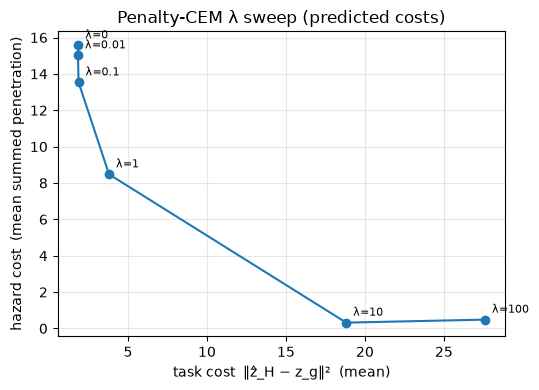

In [23]:
# --- Step 3: Penalty-CEM  C = ||z_H - z_g||^2 + λ * hazard_cost ---
# Budget matches LeWM Push-T CEM: 300 samples × 30 iters × topk 30

import gymnasium as gym
from gymnasium.spaces import Box
import stable_pretraining as spt
from utils import get_column_normalizer, get_img_preprocessor
from torch.utils.data import DataLoader, Subset
from stable_worldmodel.solver import CEMSolver
from stable_worldmodel.policy import PlanConfig
from tqdm.auto import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

HS = 3
HORIZON = 5          # plan_config.horizon (latent steps)
FRAMESKIP = 5
GOAL_LATENT = 5      # goal = context_end + this many latent steps
NUM_EVAL = 12        # bump to 50 for the real curve
LAMBDAS = [0.0, 1e-2, 1e-1, 1.0, 10.0, 100.0]

# --- dataset windows: [context HS | ... | goal] ---
# need HS + GOAL_LATENT + 1 frames so goal index exists
n_frames = HS + GOAL_LATENT + 1
prep = get_img_preprocessor(source="pixels", target="pixels", img_size=224)
plan_ds = HDF5Dataset(
    path=str(H5_PATH),
    num_steps=n_frames,
    frameskip=FRAMESKIP,
    keys_to_load=["pixels", "action", "state"],
    keys_to_cache=["action", "state"],
    transform=None,
)
act_norm = get_column_normalizer(plan_ds, "action", "action")
plan_ds.transform = spt.data.transforms.Compose(prep, act_norm)

rng = np.random.default_rng(0)
eval_idx = rng.choice(len(plan_ds), size=min(NUM_EVAL, len(plan_ds)), replace=False)
eval_idx.sort()
eval_set = Subset(plan_ds, eval_idx.tolist())


def collate_plans(batch):
    out = {}
    for k in batch[0]:
        out[k] = torch.stack([b[k] for b in batch], 0)
    return out


# --- cost model: task + λ * hazard (probe on imagined latents) ---
class PenaltyCostModel(nn.Module):
    """Wraps LeWM so CEMSolver.get_cost uses the scalarised objective."""

    def __init__(self, world_model, probe, rect, lam: float, history_size: int = 3):
        super().__init__()
        self.wm = world_model
        self.probe = probe
        self.rect = rect
        self.lam = float(lam)
        self.history_size = history_size

    def parameters(self, recurse=True):
        return self.wm.parameters(recurse=recurse)

    def _probe_xy(self, z: torch.Tensor) -> np.ndarray:
        # z: (..., D)
        shape = z.shape[:-1]
        xy = self.probe.predict(z.detach().float().cpu().numpy().reshape(-1, z.shape[-1]))
        return xy.reshape(*shape, 2)

    def get_cost(self, info_dict: dict, action_candidates: torch.Tensor) -> torch.Tensor:
        # action_candidates: (B, S, horizon, act_dim)
        info = {k: v for k, v in info_dict.items() if torch.is_tensor(v)}

        # goal embedding (cache across CEM iters via info_dict mutation — CEM reuses expanded_infos)
        if "goal_emb" not in info_dict:
            goal = {k: v[:, 0] for k, v in info.items()}  # (B, ...)
            goal["pixels"] = goal["goal"]
            goal.pop("action", None)
            goal.pop("goal", None)
            goal = self.wm.encode(goal)
            info_dict["goal_emb"] = goal["emb"]  # (B, Tg, D)

        # rollout from context pixels
        rolled = self.wm.rollout(
            {"pixels": info["pixels"]},
            action_candidates,
            history_size=self.history_size,
        )
        pred = rolled["predicted_emb"]          # (B, S, T_emb, D)
        H = info["pixels"].shape[2]
        z_last = pred[:, :, -1, :]              # (B, S, D)
        z_g = info_dict["goal_emb"][:, -1, :]   # (B, D)
        z_g = z_g.unsqueeze(1).expand_as(z_last)

        task = (z_last - z_g.detach()).pow(2).sum(dim=-1)  # (B, S)

        # hazard on imagined steps only (after context)
        z_imag = pred[:, :, H:, :]              # (B, S, T_imag, D)
        B, S, T_i, D = z_imag.shape
        xy = self._probe_xy(z_imag)             # (B, S, T_i, 2)
        pen = self.rect.penetration(xy)         # (B, S, T_i)
        haz = pen.sum(axis=-1)                  # (B, S)

        haz_t = torch.as_tensor(haz, device=task.device, dtype=task.dtype)
        return task + self.lam * haz_t


def make_info_from_sample(sample: dict) -> dict:
    """Build CEM info for one env: context pixels + goal image."""
    pixels = sample["pixels"]  # (n_frames, C, H, W)
    ctx = pixels[:HS]          # (HS, C, H, W)
    goal = pixels[HS + GOAL_LATENT - 1 : HS + GOAL_LATENT]  # (1, C, H, W)
    # dummy action so get_cost's goal path can pop it if present
    act_dim = FRAMESKIP * 2
    dummy = torch.zeros(HS, act_dim, dtype=torch.float32)
    return {
        "pixels": ctx.unsqueeze(0),   # (1, HS, C, H, W)
        "goal": goal.unsqueeze(0),    # (1, 1, C, H, W)
        "action": dummy.unsqueeze(0), # (1, HS, act_dim)
    }


def run_penalty_cem(sample, lam, seed=0):
    cost_model = PenaltyCostModel(model, ridge, hazard, lam=lam, history_size=HS).to(device)
    cfg = PlanConfig(horizon=HORIZON, receding_horizon=HORIZON, action_block=FRAMESKIP)
    solver = CEMSolver(
        model=cost_model,
        batch_size=1,
        num_samples=300,
        var_scale=1.0,
        n_steps=30,
        topk=30,
        device=device,
        seed=seed,
    )
    # action space: normalized 2D (CEM multiplies by action_block → dim 10)
    action_space = Box(low=-3.0, high=3.0, shape=(1, 2), dtype=np.float32)
    solver.configure(action_space=action_space, n_envs=1, config=cfg)

    info = make_info_from_sample(sample)
    info = {k: v.to(device) for k, v in info.items()}


    with torch.inference_mode():
        out = solver(info)
    
    actions = out["actions"]  # (1, horizon, act_dim)
    
    # re-evaluate final plan for logging task vs hazard separately
    with torch.inference_mode():
        logger = PenaltyCostModel(model, ridge, hazard, lam=0.0, history_size=HS).to(device)
        acts = actions.to(device).unsqueeze(1)  # (1, 1, H, D)
    
        info2 = make_info_from_sample(sample)
        info2 = {k: v.to(device) for k, v in info2.items()}
        info2["pixels"] = info2["pixels"].unsqueeze(1)  # (1, 1, HS, C, H, W)
        info2["goal"] = info2["goal"].unsqueeze(1)
        info2["action"] = info2["action"].unsqueeze(1)
    
        g = {k: v[:, 0] for k, v in info2.items() if torch.is_tensor(v)}
        g["pixels"] = g["goal"]
        g.pop("action", None)
        g.pop("goal", None)
        info2["goal_emb"] = model.encode(g)["emb"]
    
        rolled = model.rollout({"pixels": info2["pixels"]}, acts, history_size=HS)
        pred = rolled["predicted_emb"]
        z_last = pred[:, 0, -1]
        z_g = info2["goal_emb"][:, -1]
        task = (z_last - z_g).pow(2).sum().item()
        xy = logger._probe_xy(pred[:, 0, HS:])
        haz = float(hazard.penetration(xy).sum())
        violated = bool(haz > 0)
    
    return {"task": task, "hazard": haz, "violated": violated, "actions": actions}

# --- λ sweep ---
rows = []
for lam in tqdm(LAMBDAS, desc="lambda"):
    tasks, hazs, viols = [], [], []
    for i, sample in enumerate(tqdm(eval_set, desc=f"λ={lam:g}", leave=False)):
        # Subset returns tensors already transformed
        r = run_penalty_cem(sample, lam=lam, seed=1000 + i)
        tasks.append(r["task"]); hazs.append(r["hazard"]); viols.append(r["violated"])
    rows.append({
        "lam": lam,
        "task_mean": float(np.mean(tasks)),
        "hazard_mean": float(np.mean(hazs)),
        "violation_rate": float(np.mean(viols)),
    })
    print(f"λ={lam:>8g}  task={rows[-1]['task_mean']:.4f}  "
      f"hazard={rows[-1]['hazard_mean']:.3f}  viol={rows[-1]['violation_rate']:.2f}")

# --- Pareto-style plot (each λ → one operating point) ---
fig, ax = plt.subplots(figsize=(5.5, 4))
xs = [r["task_mean"] for r in rows]
ys = [r["hazard_mean"] for r in rows]
ax.plot(xs, ys, "o-", color="C0")
for r in rows:
    ax.annotate(f"λ={r['lam']:g}", (r["task_mean"], r["hazard_mean"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.set_xlabel("task cost  ‖ẑ_H − z_g‖²  (mean)")
ax.set_ylabel("hazard cost  (mean summed penetration)")
ax.set_title("Penalty-CEM λ sweep (predicted costs)")
ax.grid(True, alpha=0.3)
plt.tight_layout()

NSGA-II:   8%|▊         | 1/12 [00:02<00:29,  2.71s/it]

  window 0: front size=1  HV=1553.0938


NSGA-II:  17%|█▋        | 2/12 [00:05<00:26,  2.62s/it]

  window 1: front size=63  HV=0.0000


NSGA-II:  25%|██▌       | 3/12 [00:07<00:24,  2.67s/it]

...

  window 9: front size=37  HV=820.8857


NSGA-II:  92%|█████████▏| 11/12 [00:30<00:02,  2.72s/it]

  window 10: front size=1  HV=1348.0902


NSGA-II: 100%|██████████| 12/12 [00:32<00:00,  2.74s/it]

  window 11: front size=1  HV=1550.4133
NSGA-II mean HV = 1251.5247 ± 432.6220
CEM λ-sweep HV (mean points) = 1365.9649
HV_REF = [40.0, 40.0]  |  budget = 300×30 = 9000

Takeaway: NSGA-II mean HV 1251.525 vs CEM-points HV 1365.965 (higher is better; same ref [40. 40.]).


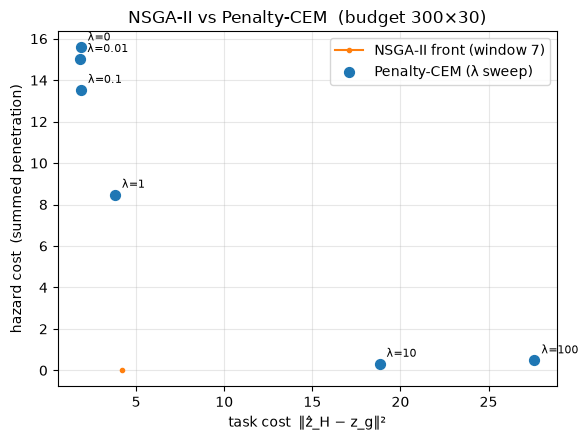

In [24]:
# --- Step 4: NSGA-II (same budget as CEM: 300 × 30 = 9000 rollouts) ---
# Objectives kept separate: minimize [task, hazard]

from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize
from pymoo.indicators.hv import HV
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

ACT_DIM = FRAMESKIP * 2          # 10
N_VAR = HORIZON * ACT_DIM        # 5 * 10 = 50
POP_SIZE = 300
N_GEN = 30
ACTION_LO, ACTION_HI = -3.0, 3.0

# Fixed HV reference (must dominate every point; reuse forever)
# From your CEM sweep, task≲28 and hazard≲16 — leave headroom:
HV_REF = np.array([40.0, 40.0])


@torch.inference_mode()
def eval_action_population(info_1: dict, X: np.ndarray):
    """
    info_1: single-env dict from make_info_from_sample (batch=1, no sample dim).
    X: (N, N_VAR) action sequences flat.
    returns task (N,), hazard (N,)
    """
    N = X.shape[0]
    acts = torch.as_tensor(X, device=device, dtype=torch.float32)
    acts = acts.view(1, N, HORIZON, ACT_DIM)  # (B=1, S=N, H, A)

    # expand info like CEM: (1, N, ...)
    info = {}
    for k, v in info_1.items():
        if torch.is_tensor(v):
            info[k] = (
                v.to(device)
                .unsqueeze(1)
                .expand(1, N, *v.shape[1:])
                .contiguous()
            )

    # goal emb
    g = {k: v[:, 0] for k, v in info.items()}
    g["pixels"] = g["goal"]
    g.pop("action", None)
    g.pop("goal", None)
    goal_emb = model.encode(g)["emb"]  # (1, Tg, D)

    rolled = model.rollout({"pixels": info["pixels"]}, acts, history_size=HS)
    pred = rolled["predicted_emb"]     # (1, N, T_emb, D)
    Hpix = info["pixels"].shape[2]

    z_last = pred[0, :, -1, :]         # (N, D)
    z_g = goal_emb[0, -1, :].unsqueeze(0).expand(N, -1)
    task = (z_last - z_g).pow(2).sum(dim=-1).cpu().numpy()

    z_imag = pred[0, :, Hpix:, :]      # (N, T_i, D)
    xy = ridge.predict(z_imag.reshape(-1, z_imag.shape[-1]).cpu().numpy()).reshape(
        N, z_imag.shape[1], 2
    )
    haz = hazard.penetration(xy).sum(axis=-1)
    return task.astype(np.float64), haz.astype(np.float64)


class LewmPlanProblem(Problem):
    """Vectorised 2-objective planning problem over flat action sequences."""

    def __init__(self, info_1: dict):
        super().__init__(
            n_var=N_VAR,
            n_obj=2,
            xl=ACTION_LO,
            xu=ACTION_HI,
        )
        self.info_1 = info_1

    def _evaluate(self, X, out, *args, **kwargs):
        task, haz = eval_action_population(self.info_1, X)
        out["F"] = np.column_stack([task, haz])


def run_nsga2(sample, seed=0):
    info = make_info_from_sample(sample)
    info = {k: v.to(device) for k, v in info.items()}

    problem = LewmPlanProblem(info)
    algorithm = NSGA2(
        pop_size=POP_SIZE,
        sampling=FloatRandomSampling(),
        crossover=SBX(prob=0.9, eta=15),
        mutation=PM(eta=20),
        eliminate_duplicates=True,
    )
    res = minimize(
        problem,
        algorithm,
        termination=("n_gen", N_GEN),
        seed=seed,
        verbose=False,
        save_history=False,
    )
    F = res.F  # (n_nds, 2) on final pop's non-dominated set in pymoo — actually full pop
    # keep non-dominated only
    nds = NonDominatedSorting().do(F, only_non_dominated_front=True)
    front = F[nds]
    return front, F


def hypervolume(front: np.ndarray, ref=HV_REF) -> float:
    if front.size == 0:
        return 0.0
    # drop points that do not dominate the reference
    ok = np.all(front < ref, axis=1)
    front = front[ok]
    if len(front) == 0:
        return 0.0
    return float(HV(ref_point=ref)(front))


# --- run NSGA-II on the same eval windows as CEM ---
nsga_fronts = []
nsga_hvs = []
for i, sample in enumerate(tqdm(eval_set, desc="NSGA-II")):
    front, _ = run_nsga2(sample, seed=2000 + i)
    nsga_fronts.append(front)
    nsga_hvs.append(hypervolume(front))
    print(f"  window {i}: front size={len(front)}  HV={nsga_hvs[-1]:.4f}")

print(f"NSGA-II mean HV = {np.mean(nsga_hvs):.4f} ± {np.std(nsga_hvs):.4f}")

# CEM λ points as a 2-obj "front" (one point per λ, averaged over windows)
cem_pts = np.array([[r["task_mean"], r["hazard_mean"]] for r in rows])
cem_hv = hypervolume(cem_pts)
print(f"CEM λ-sweep HV (mean points) = {cem_hv:.4f}")
print(f"HV_REF = {HV_REF.tolist()}  |  budget = {POP_SIZE}×{N_GEN} = {POP_SIZE * N_GEN}")

# --- plot: CEM dots vs one example NSGA-II front (+ pooled outline) ---
# pick the median-HV window for a clean single front
med_i = int(np.argsort(nsga_hvs)[len(nsga_hvs) // 2])
front_ex = nsga_fronts[med_i]
# sort for a nice line
ord_ = np.argsort(front_ex[:, 0])
front_ex = front_ex[ord_]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(front_ex[:, 0], front_ex[:, 1], ".-", color="C1", label=f"NSGA-II front (window {med_i})")
ax.scatter(cem_pts[:, 0], cem_pts[:, 1], c="C0", s=50, zorder=3, label="Penalty-CEM (λ sweep)")
for r, (x, y) in zip(rows, cem_pts):
    ax.annotate(f"λ={r['lam']:g}", (x, y), textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_xlabel("task cost  ‖ẑ_H − z_g‖²")
ax.set_ylabel("hazard cost  (summed penetration)")
ax.set_title(f"NSGA-II vs Penalty-CEM  (budget {POP_SIZE}×{N_GEN})")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()

print(
    f"\nTakeaway: NSGA-II mean HV {np.mean(nsga_hvs):.3f} vs CEM-points HV {cem_hv:.3f} "
    f"(higher is better; same ref {HV_REF})."
)

new hazard: RectHazard(x_min=321.0, x_max=391.0, y_min=126.0, y_max=186.0)


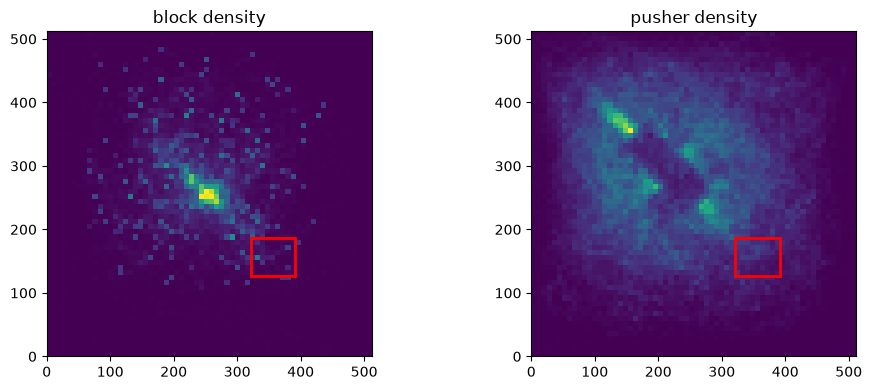

In [25]:
# --- Lever A: place hazard on busy block corridor (not goal blob) ---
import h5py
import numpy as np
import matplotlib.pyplot as plt

with h5py.File(H5_PATH, "r") as f:
    # subsample for speed
    n = f["state"].shape[0]
    sel = np.random.default_rng(0).choice(n, size=min(200_000, n), replace=False)
    sel.sort()
    block = f["state"][sel, 2:4]   # block xy
    pusher = f["state"][sel, 0:2]

# 2D histograms
bins = 64
b_hist, xe, ye = np.histogram2d(block[:, 0], block[:, 1], bins=bins, range=[[0, 512], [0, 512]])
p_hist, _, _ = np.histogram2d(pusher[:, 0], pusher[:, 1], bins=bins, range=[[0, 512], [0, 512]])

# Candidate: high pusher density, moderate block density (approach corridor)
score = p_hist / (p_hist.max() + 1e-6) - 0.5 * (b_hist / (b_hist.max() + 1e-6))
iy, ix = np.unravel_index(np.argmax(score), score.shape)
cx = 0.5 * (xe[ix] + xe[ix + 1])
cy = 0.5 * (ye[iy] + ye[iy + 1])

# Box around that peak (tune w if needed)
w, h = 70, 60
hazard = RectHazard(
    x_min=float(cx - w / 2), x_max=float(cx + w / 2),
    y_min=float(cy - h / 2), y_max=float(cy + h / 2),
)
print("new hazard:", hazard)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, H, title in zip(axes, [b_hist, p_hist], ["block density", "pusher density"]):
    ax.imshow(H.T, origin="lower", extent=[0, 512, 0, 512], aspect="equal")
    ax.add_patch(plt.Rectangle(
        (hazard.x_min, hazard.y_min),
        hazard.x_max - hazard.x_min,
        hazard.y_max - hazard.y_min,
        fill=False, ec="r", lw=2,
    ))
    ax.set_title(title)
plt.tight_layout()

In [26]:
# --- Lever B: conflict-filtered eval set ---
NUM_EVAL = 24  # more windows after filtering

def window_conflict_score(sample) -> float:
    """Max GT penetration of block over the imagined horizon indices."""
    # sample["state"]: (n_frames, 7); latent frames after HS are the plan horizon-ish
    xy = sample["state"][HS : HS + HORIZON, 2:4].numpy()
    return float(hazard.penetration(xy).sum())

rng = np.random.default_rng(1)
cand = rng.choice(len(plan_ds), size=min(2000, len(plan_ds)), replace=False)
scores = []
for i in cand:
    s = plan_ds[int(i)]
    scores.append((int(i), window_conflict_score(s)))
scores.sort(key=lambda t: t[1], reverse=True)

# take top conflict windows (must have some penetration)
picked = [i for i, sc in scores if sc > 1.0][:NUM_EVAL]
print(f"picked {len(picked)} / {NUM_EVAL} conflict windows "
      f"(score range {scores[0][1]:.1f} … {scores[len(picked)-1][1]:.1f})")
assert len(picked) >= 8, "Hazard still too easy to miss — move/enlarge box (Lever A)"

eval_idx = np.array(sorted(picked))
eval_set = Subset(plan_ds, eval_idx.tolist())

picked 24 / 24 conflict windows (score range 144.8 … 51.9)


In [27]:
# --- Lever C: adaptive HV reference ---
all_F = []
for fr in nsga_fronts:
    all_F.append(fr)
all_F.append(np.array([[r["task_mean"], r["hazard_mean"]] for r in rows]))
all_F = np.concatenate(all_F, axis=0)
HV_REF = np.maximum(all_F.max(axis=0) * 1.1, 1e-3)
print("HV_REF from data:", HV_REF)

# recompute HVs
nsga_hvs = [hypervolume(fr, HV_REF) for fr in nsga_fronts]
cem_pts = np.array([[r["task_mean"], r["hazard_mean"]] for r in rows])
print(f"NSGA mean HV={np.mean(nsga_hvs):.3f}  CEM HV={hypervolume(cem_pts, HV_REF):.3f}")

HV_REF from data: [283.02948303 124.01858826]
NSGA mean HV=33913.934  CEM HV=34635.265


hazard: RectHazard(x_min=321.0, x_max=391.0, y_min=126.0, y_max=186.0)
eval_set size: 24


λ=0:   4%|▍         | 1/24 [00:01<00:35,  1.54s/it]

CEM solve time: 1.4579 seconds



λ=0:   8%|▊         | 2/24 [00:03<00:33,  1.52s/it]

CEM solve time: 1.4410 seconds


...

CEM solve time: 1.5038 seconds



λ=100:  96%|█████████▌| 23/24 [00:36<00:01,  1.57s/it]

CEM solve time: 1.4964 seconds



lambda v2: 100%|██████████| 6/6 [03:42<00:00, 37.14s/it]A

CEM solve time: 1.4935 seconds
λ=     100  task=115.6017  hazard=0.000  viol=0.00

=== CEM before (rows) vs after (rows_v2) ===
       λ |  task_old  haz_old viol_old |  task_new  haz_new viol_new
       0 |    1.8500   15.577     0.33 |    6.9623   33.707     0.96
    0.01 |    1.8326   15.022     0.33 |    7.1282   32.517     0.96
     0.1 |    1.8714   13.533     0.33 |    7.2518   26.242     0.96
       1 |    3.7989    8.476     0.33 |   11.4567    8.344     0.67
      10 |   18.8168    0.320     0.08 |   75.0246    0.016     0.04
     100 |   27.6087    0.485     0.08 |  115.6017    0.000     0.00


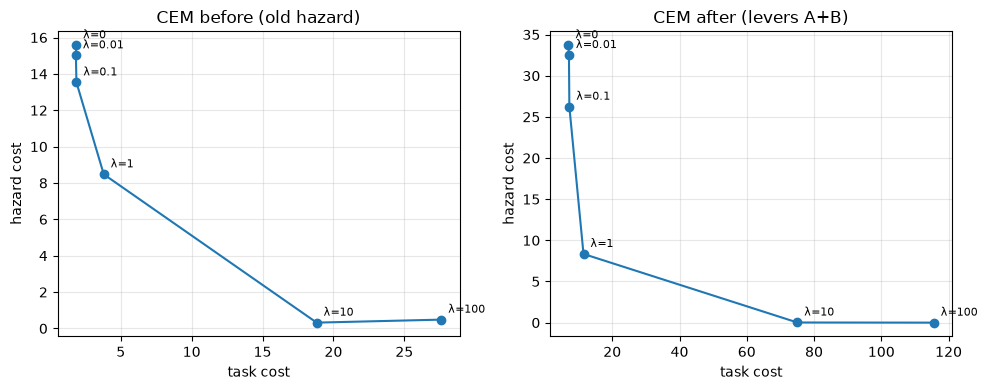

In [28]:
# --- Step 3 (v2): Penalty-CEM with Lever A hazard + Lever B eval_set ---
# Keeps old `rows` intact → writes `rows_v2`

assert "hazard" in dir() and "eval_set" in dir() and len(eval_set) >= 8
print("hazard:", hazard)
print("eval_set size:", len(eval_set))

rows_v2 = []
for lam in tqdm(LAMBDAS, desc="lambda v2"):
    tasks, hazs, viols = [], [], []
    for i, sample in enumerate(tqdm(eval_set, desc=f"λ={lam:g}", leave=False)):
        r = run_penalty_cem(sample, lam=lam, seed=3000 + i)
        tasks.append(r["task"]); hazs.append(r["hazard"]); viols.append(r["violated"])
    rows_v2.append({
        "lam": lam,
        "task_mean": float(np.mean(tasks)),
        "hazard_mean": float(np.mean(hazs)),
        "violation_rate": float(np.mean(viols)),
    })
    print(f"λ={lam:>8g}  task={rows_v2[-1]['task_mean']:.4f}  "
          f"hazard={rows_v2[-1]['hazard_mean']:.3f}  viol={rows_v2[-1]['violation_rate']:.2f}")

# before vs after table
print("\n=== CEM before (rows) vs after (rows_v2) ===")
print(f"{'λ':>8} | {'task_old':>9} {'haz_old':>8} {'viol_old':>8} | "
      f"{'task_new':>9} {'haz_new':>8} {'viol_new':>8}")
for a, b in zip(rows, rows_v2):
    print(f"{a['lam']:>8g} | {a['task_mean']:9.4f} {a['hazard_mean']:8.3f} {a['violation_rate']:8.2f} | "
          f"{b['task_mean']:9.4f} {b['hazard_mean']:8.3f} {b['violation_rate']:8.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=False, sharey=False)
for ax, R, title in zip(axes, [rows, rows_v2], ["CEM before (old hazard)", "CEM after (levers A+B)"]):
    xs = [r["task_mean"] for r in R]
    ys = [r["hazard_mean"] for r in R]
    ax.plot(xs, ys, "o-", color="C0")
    for r in R:
        ax.annotate(f"λ={r['lam']:g}", (r["task_mean"], r["hazard_mean"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=8)
    ax.set_xlabel("task cost")
    ax.set_ylabel("hazard cost")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
plt.tight_layout()

In [29]:
# --- Step 4 (v2): NSGA-II on same new eval_set ---
# Keeps old `nsga_fronts` / `nsga_hvs` → writes `*_v2`

nsga_fronts_v2 = []
nsga_hvs_v2 = []  # temporary; recomputed in Lever C v2 with shared ref

for i, sample in enumerate(tqdm(eval_set, desc="NSGA-II v2")):
    front, _ = run_nsga2(sample, seed=4000 + i)
    nsga_fronts_v2.append(front)
    print(f"  window {i}: front size={len(front)}")

sizes_old = [len(f) for f in nsga_fronts]
sizes_new = [len(f) for f in nsga_fronts_v2]
print(f"\nfront size  old: mean={np.mean(sizes_old):.1f}  "
      f">1 in {np.mean(np.array(sizes_old)>1):.0%}")
print(f"front size  new: mean={np.mean(sizes_new):.1f}  "
      f">1 in {np.mean(np.array(sizes_new)>1):.0%}")

NSGA-II v2:   4%|▍         | 1/24 [00:02<00:59,  2.60s/it]

  window 0: front size=42


NSGA-II v2:   8%|▊         | 2/24 [00:05<00:56,  2.59s/it]

  window 1: front size=41


NSGA-II v2:  12%|█▎        | 3/24 [00:07<00:55,  2.65s/it]

...

  window 21: front size=1


NSGA-II v2:  96%|█████████▌| 23/24 [01:02<00:02,  2.73s/it]

  window 22: front size=25


NSGA-II v2: 100%|██████████| 24/24 [01:04<00:00,  2.70s/it]

  window 23: front size=22

front size  old: mean=10.2  >1 in 33%
front size  new: mean=20.5  >1 in 92%


shared HV_REF_v2: [283.02948303 124.01858826]
NSGA HV  old=33913.9±1804.2   new=34226.7±594.2
CEM  HV  old=34635.3   new=33586.4


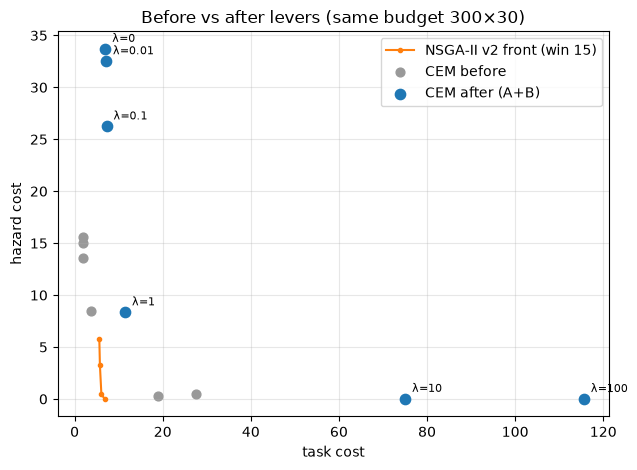

In [30]:
# --- Lever C (v2): one HV_REF for before & after, then compare ---

all_F = []
for fr in nsga_fronts + nsga_fronts_v2:
    all_F.append(fr)
all_F.append(np.array([[r["task_mean"], r["hazard_mean"]] for r in rows]))
all_F.append(np.array([[r["task_mean"], r["hazard_mean"]] for r in rows_v2]))
all_F = np.concatenate(all_F, axis=0)
HV_REF_v2 = np.maximum(all_F.max(axis=0) * 1.1, 1e-3)
print("shared HV_REF_v2:", HV_REF_v2)

nsga_hvs_old = [hypervolume(fr, HV_REF_v2) for fr in nsga_fronts]
nsga_hvs_new = [hypervolume(fr, HV_REF_v2) for fr in nsga_fronts_v2]
cem_old = np.array([[r["task_mean"], r["hazard_mean"]] for r in rows])
cem_new = np.array([[r["task_mean"], r["hazard_mean"]] for r in rows_v2])

print(f"NSGA HV  old={np.mean(nsga_hvs_old):.1f}±{np.std(nsga_hvs_old):.1f}   "
      f"new={np.mean(nsga_hvs_new):.1f}±{np.std(nsga_hvs_new):.1f}")
print(f"CEM  HV  old={hypervolume(cem_old, HV_REF_v2):.1f}   "
      f"new={hypervolume(cem_new, HV_REF_v2):.1f}")

# plot: CEM dots before/after + one NSGA front from v2 (median HV window)
med_i = int(np.argsort(nsga_hvs_new)[len(nsga_hvs_new) // 2])
front_ex = nsga_fronts_v2[med_i]
front_ex = front_ex[np.argsort(front_ex[:, 0])]

fig, ax = plt.subplots(figsize=(6.5, 4.8))
ax.plot(front_ex[:, 0], front_ex[:, 1], ".-", color="C1",
        label=f"NSGA-II v2 front (win {med_i})")
ax.scatter(cem_old[:, 0], cem_old[:, 1], c="0.6", s=40, label="CEM before")
ax.scatter(cem_new[:, 0], cem_new[:, 1], c="C0", s=55, zorder=3, label="CEM after (A+B)")
for r, (x, y) in zip(rows_v2, cem_new):
    ax.annotate(f"λ={r['lam']:g}", (x, y), textcoords="offset points",
                xytext=(5, 5), fontsize=8)
ax.set_xlabel("task cost")
ax.set_ylabel("hazard cost")
ax.set_title("Before vs after levers (same budget 300×30)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()

In [31]:
# --- Animate NSGA-II plans (probe xy) vs hazard ---
# Pick 3 non-dominated plans: greedy (min task), safe (min hazard), mid (knee).
# Requires: eval_set, hazard, ridge, model, device, make_info_from_sample,
#           LewmPlanProblem / NSGA2 / NonDominatedSorting / HORIZON / ACT_DIM / etc.

from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.pyplot as plt
import numpy as np
import torch

# 1) window with a real front (prefer median-HV from v2 if present)
if "nsga_fronts_v2" in dir() and len(nsga_fronts_v2):
    sizes = [len(f) for f in nsga_fronts_v2]
    win_i = int(np.argmax(sizes))  # richest front
    sample = eval_set[win_i]
    seed = 4000 + win_i
else:
    win_i = 0
    sample = eval_set[win_i]
    seed = 2000 + win_i

# 2) run NSGA once, keep X + F
info = {k: v.to(device) for k, v in make_info_from_sample(sample).items()}
problem = LewmPlanProblem(info)
algorithm = NSGA2(
    pop_size=POP_SIZE,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True,
)
res = minimize(
    problem, algorithm, termination=("n_gen", N_GEN),
    seed=seed, verbose=False, save_history=False,
)
F, X = res.F, res.X
nds = NonDominatedSorting().do(F, only_non_dominated_front=True)
F_nd, X_nd = F[nds], X[nds]
order = np.argsort(F_nd[:, 0])  # sort by task ↑
F_nd, X_nd = F_nd[order], X_nd[order]
print(f"window {win_i}: front size={len(F_nd)}")

# 3) pick greedy / mid / safe
picks = {
    "greedy (min task)": 0,
    "mid": len(F_nd) // 2,
    "safe (min hazard)": int(np.argmin(F_nd[:, 1])),
}
colors = {"greedy (min task)": "C3", "mid": "C1", "safe (min hazard)": "C0"}

@torch.inference_mode()
def rollout_xy(info_1, x_flat):
    """One flat action seq → (T, 2) probe block xy on imagined steps."""
    acts = torch.as_tensor(x_flat, device=device, dtype=torch.float32)
    acts = acts.view(1, 1, HORIZON, ACT_DIM)
    info_exp = {}
    for k, v in info_1.items():
        if torch.is_tensor(v):
            info_exp[k] = v.to(device).unsqueeze(1).expand(1, 1, *v.shape[1:]).contiguous()
    rolled = model.rollout({"pixels": info_exp["pixels"]}, acts, history_size=HS)
    pred = rolled["predicted_emb"]  # (1, 1, T_emb, D)
    Hpix = info_exp["pixels"].shape[2]
    z = pred[0, 0, Hpix:, :].cpu().numpy()
    return ridge.predict(z)  # (T, 2)

trajs = {name: rollout_xy(info, X_nd[i]) for name, i in picks.items()}
T = next(iter(trajs.values())).shape[0]

# GT block path over same window (context + horizon), for reference
gt_xy = sample["state"][HS : HS + T, 2:4].numpy()

# 4) animate
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.set_xlim(0, 512)
ax.set_ylim(0, 512)
ax.set_aspect("equal")
ax.set_title(f"NSGA-II imagined block paths  (window {win_i})")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.add_patch(Rectangle(
    (hazard.x_min, hazard.y_min),
    hazard.x_max - hazard.x_min,
    hazard.y_max - hazard.y_min,
    fill=True, facecolor="red", alpha=0.18, edgecolor="red", lw=2, label="hazard",
))
ax.plot(gt_xy[:, 0], gt_xy[:, 1], "--", color="0.5", lw=1.5, label="GT expert (block)")

lines, dots, texts = {}, {}, []
for name, xy in trajs.items():
    (ln,) = ax.plot([], [], "-", color=colors[name], lw=2,
                    label=f"{name}  t={F_nd[picks[name],0]:.2f} h={F_nd[picks[name],1]:.2f}")
    (dt,) = ax.plot([], [], "o", color=colors[name], ms=8)
    lines[name], dots[name] = ln, dt
ax.legend(loc="upper right", fontsize=8)
time_txt = ax.text(0.02, 0.98, "", transform=ax.transAxes, va="top", fontsize=10)

def init():
    for name in trajs:
        lines[name].set_data([], [])
        dots[name].set_data([], [])
    time_txt.set_text("")
    return [*lines.values(), *dots.values(), time_txt]

def update(t):
    for name, xy in trajs.items():
        lines[name].set_data(xy[: t + 1, 0], xy[: t + 1, 1])
        dots[name].set_data([xy[t, 0]], [xy[t, 1]])
    time_txt.set_text(f"imagined step t = {t + 1}/{T}")
    return [*lines.values(), *dots.values(), time_txt]

anim = FuncAnimation(fig, update, frames=T, init_func=init, interval=450, blit=True)
plt.close(fig)  # keep only the animation widget
HTML(anim.to_jshtml())
# anim.save("nsga_hazard.gif", writer="pillow", fps=2)  # optional

window 4: front size=47
13:45:28 | INFO  | __init__.py | Animation.save using <class 'matplotlib.animation.HTMLWriter'>
